In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math
import ternary
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist
from mpl_toolkits.mplot3d import Axes3D
from Functions_sirbu_loreto import *
from scipy.spatial.distance import pdist, squareform

# ANDAMENTO ENTROPIA - OVERLAP 

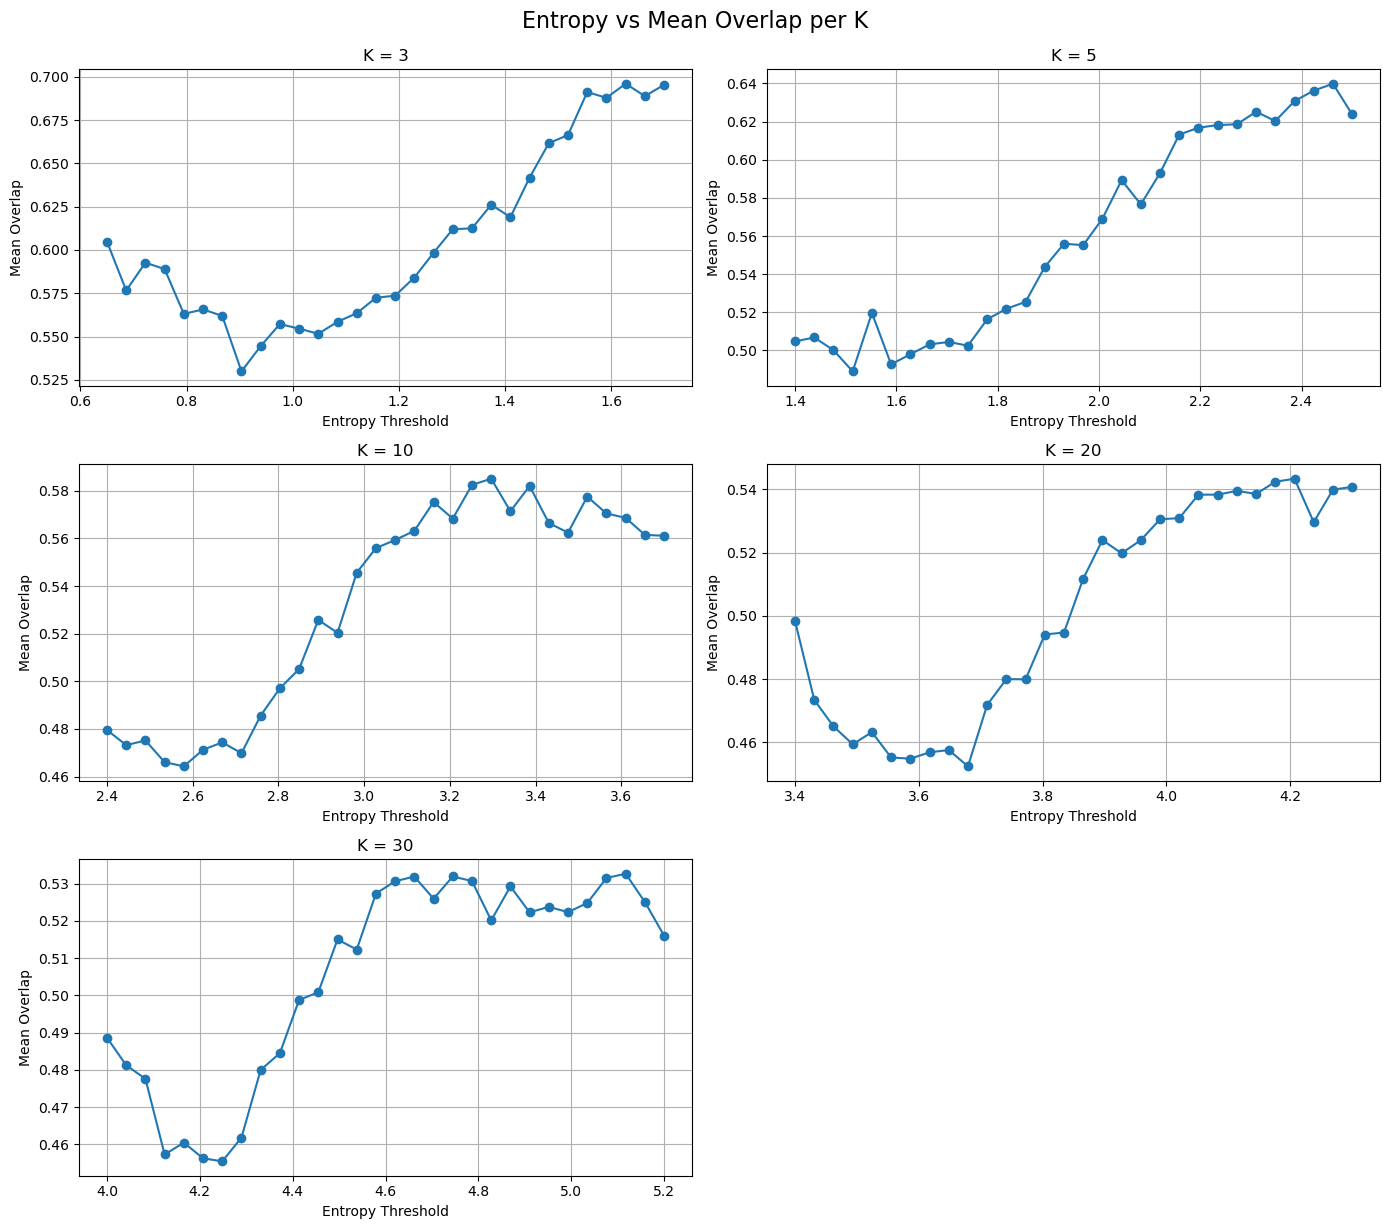

In [2]:


entropy_values = []
overlap_values = []
runs_dict = {}
num_run = 3
N = 100
n_points = 30  # Assicurati che sia definito

entropy_ranges = {
    3: np.linspace(0.65, 1.7, n_points),
    5: np.linspace(1.4, 2.5, n_points),
    10: np.linspace(2.4, 3.7, n_points),
    20: np.linspace(3.4, 4.3, n_points),
    30: np.linspace(4.0, 5.2, n_points),
}

fig, axs = plt.subplots(3, 2, figsize=(14, 12))
axs = axs.flatten()

for idx, (K, entropies) in enumerate(entropy_ranges.items()): 
    runs_dict = {}
    for i in range(num_run):
        runs_dict[i] = {}
        entropy_values = []
        overlap_values = []
        runs_dict[i]['entropy'] =  []
        runs_dict[i]['overlap'] = []

        for entropy_threshold in entropies:
            pop = generate_population(K, N, entropy_threshold)
            entropy_values.append(entropy_threshold)
            overlap = calculate_total_overlap(pop)
            overlap_values.append(overlap)

        runs_dict[i]['entropy'] = entropy_values
        runs_dict[i]['overlap'] = overlap_values

    num_thresholds = len(runs_dict[0]['overlap'])
    mean_overlaps = []
    entropy_values = runs_dict[0]['entropy']

    for j in range(num_thresholds):
        overlaps_at_j = [runs_dict[i]['overlap'][j] for i in range(num_run)]
        mean_overlaps.append(np.mean(overlaps_at_j))

    axs[idx].plot(entropy_values, mean_overlaps, marker='o', linestyle='-')
    axs[idx].set_title(f'K = {K}')
    axs[idx].set_xlabel('Entropy Threshold')
    axs[idx].set_ylabel('Mean Overlap')
    axs[idx].grid(True)

# Se ci sono meno di 6 subplot, nascondi quelli vuoti
for i in range(len(entropy_ranges), len(axs)):
    axs[i].axis('off')

plt.tight_layout()
plt.suptitle('Entropy vs Mean Overlap per K', fontsize=16, y=1.02)
plt.show()


# LET'S VERIFY PAPER VALUE FOR K=3 overlap-entropy

Popolazione nel simplesso con Initial Overlap = 0.59 S_trashold = 1.20


C:\Users\alice\anaconda3.1\Lib\site-packages\ternary\plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


Popolazione nel simplesso con Initial Overlap = 0.66 S_trashold = 1.50
Popolazione nel simplesso con Initial Overlap = 0.69 S_trashold = 1.60


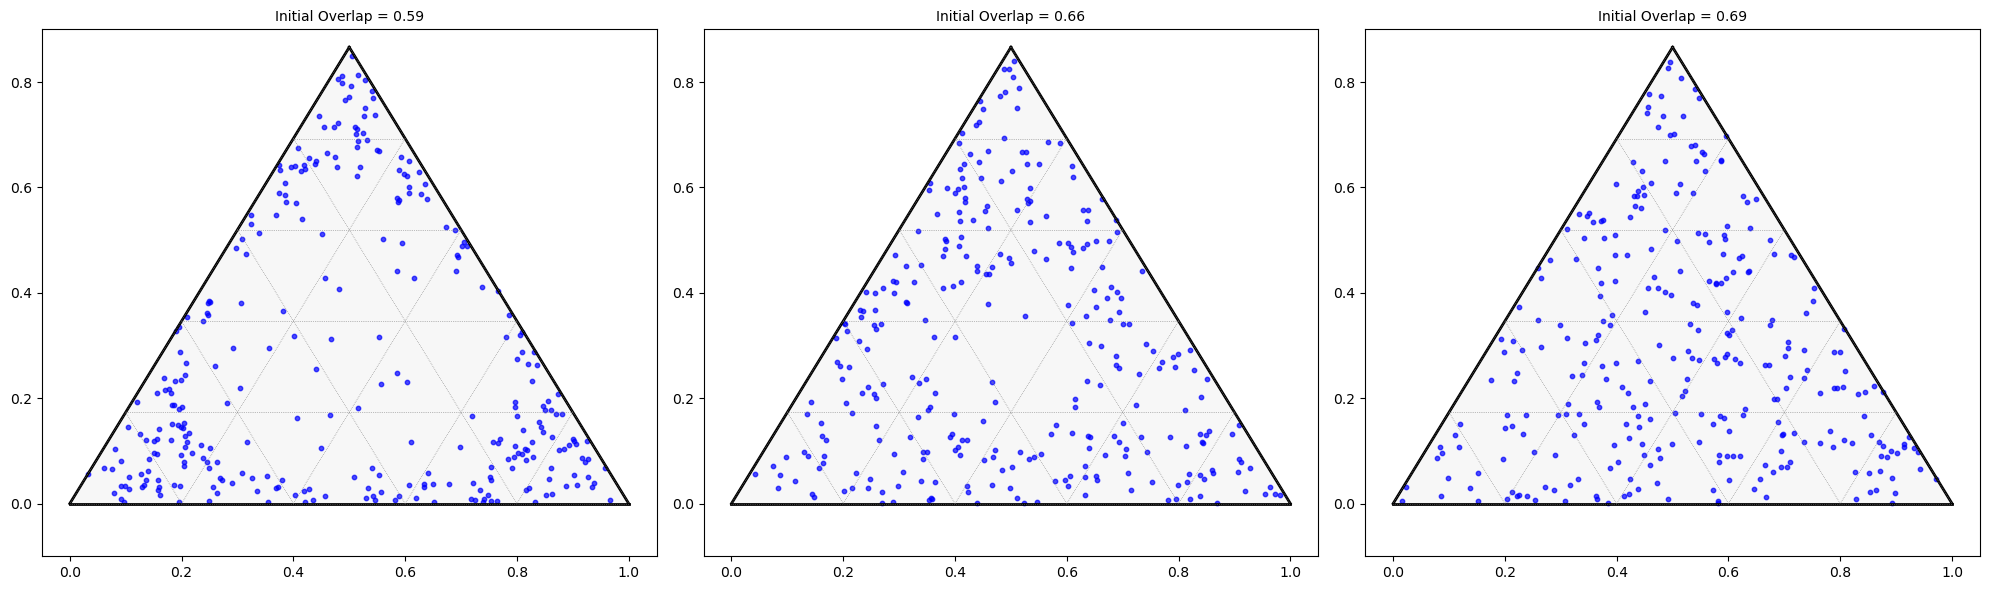

In [3]:
entropy_threshold_values = [1.2 ,1.5, 1.6]
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
K = 3
N = 300
for i, entropy_threshold in enumerate(entropy_threshold_values):
    pop = generate_population(K , N, entropy_threshold)
    o = calculate_total_overlap(pop)
    print(f"Popolazione nel simplesso con Initial Overlap = {o:.2f} S_trashold = {entropy_threshold:.2f}")
    title = f'Initial Overlap = {o:.2f}'
    plot_simplesso_with_ax(pop, axes[i], title)

plt.tight_layout()
plt.savefig('GENERATE POPULATION')
plt.show()

# ORA  EVOLVIAMO LA POPOLAZIONE 

In [ ]:
entropy_threshold =  1.2
alpha = 0.0167
N = 300
K=3
eps = 0.1
for time in [500, 5000, 50000]:
    fig, axes = plt.subplots(1, 2, figsize=(12, 6)) 
    popolazione_iniziale = generate_population(K,N, entropy_threshold)
    o = calculate_total_overlap(popolazione_iniziale)
    plt.suptitle(rf"Evoluzione solo con peer interaction: $t$ = {time}  $\alpha$ = {alpha:.2f}  $\epsilon$ = {eps:.2f} ", fontsize=14,  fontweight='bold')

    plot_simplesso_with_ax(popolazione_iniziale, axes[0], rf"Popolazione Iniziale ,$\bar{{o}}$ = {o:.2f}")
    pop_evoluta, storico= evolve_population( popolazione_iniziale , time , eps, alpha) 
    final_o =  calculate_total_overlap(pop_evoluta)
    title = f'traiettoria'

    print('FINAL COHESION VALUE' , final_o )
    plot_simplesso_with_ax(pop_evoluta, axes[1], rf"Popolazione Finale, $\bar{{o}}$ = {final_o:.2f}")
    plt.tight_layout()
    plt.show()
    fig, ax = plt.subplots(figsize=(6, 6))
    index_user = 3 # Cambia questo per tracciare un altro individuo
    plot_user_trajectory_from_dict(storico, index_user, ax)
    plot_user_trajectory_from_dict(storico, 10, ax)
    plot_user_trajectory_from_dict(storico, 205, ax)
    plot_user_trajectory_from_dict(storico, 50, ax)
    
    plt.show()

# PARTE DI CLUSTERING

In [25]:
high_overlap = 1.6
low_overlap = 0.95

pop_high = generate_population(3 , 100, high_overlap)
pop_low =  generate_population(3 , 100, low_overlap) 

pop_finale_high, storico = evolve_population( pop_high , 10000 , 0.1, 0.0167 )
pop_finale_low , storico =evolve_population( pop_low , 10000 , 0.1, 0.0167 )


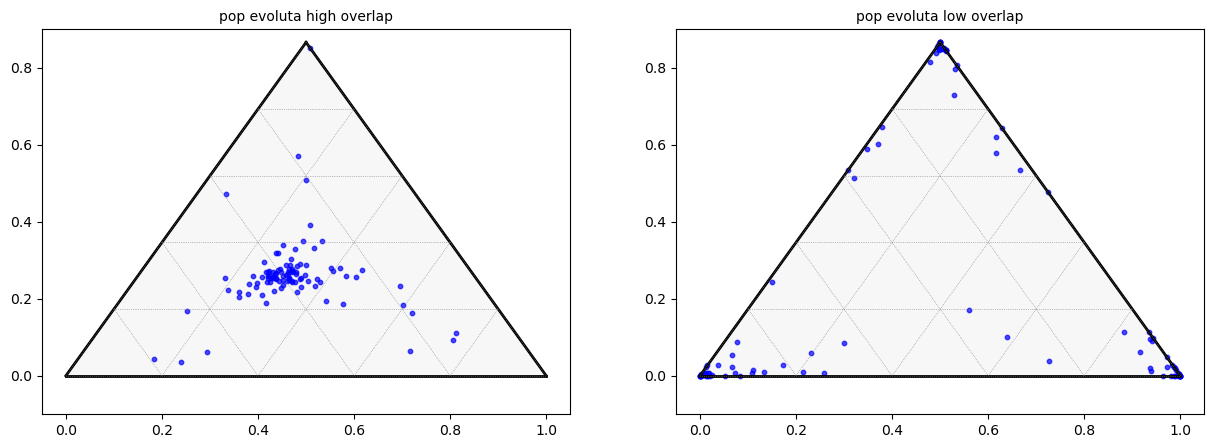

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_simplesso_with_ax(pop_finale_high,axes[0], 'pop evoluta high overlap')
plot_simplesso_with_ax(pop_finale_low ,axes[1], 'pop evoluta low overlap')

In [3]:
def hierarchical_clustering_K(population, similarity_threshold=0.8):
  
    similarity_matrix = compute_overlap_matrix(population)
    indices_over_one = np.argwhere(similarity_matrix > 1)

    # Stampa gli indici e i relativi valori
    for i, j in indices_over_one:
        similarity_matrix[i][j] = 1 
    distance_matrix = 1 - similarity_matrix
    condensed_distance = squareform(distance_matrix, checks=False)
    linkage_matrix = linkage(condensed_distance, method='complete')
    
    distance_threshold = 1 - similarity_threshold
    K = len(population[0])
    cluster_labels = fcluster(linkage_matrix, t = similarity_threshold , criterion='distance')

    return cluster_labels

In [28]:
labels_high = hierarchical_clustering_K(pop_finale_high, similarity_threshold=0.8)
labels_low  = hierarchical_clustering_K(pop_finale_low, similarity_threshold=0.8)


pr_high = compute_PR(labels_high)
pr_low  = compute_PR(labels_low)

print("PR high:", pr_high)  # Ci si aspetta PR ≈ 1
print("PR low:", pr_low)    # Ci si aspetta PR ≈ 3 (o comunque un valore più alto)

PR high: 1.0831889081455806
PR low: 2.9815146094215863


In [5]:
popolazioni = {}
Ks = [3,5,10]
eps = 0.1
alphas = [0.0167, 0.01 , 0.005 , 0.0025 , 0.00167]
times = [ 100000,3000000,10000000,3000000,500000 ]
n_points = 100
entropy_ranges = {
    3: np.linspace(0.8, 1.6, n_points),
    5: np.linspace(1.6, 2.4, n_points),
    10: np.linspace(2.5, 3.7, n_points),
    20: np.linspace(3.6, 4.3, n_points),
    30: np.linspace(4.2, 5.5, n_points),
}

for i in range(1):
    print('K', Ks[i])
    alpha = alphas[i]
    K = Ks[i]
    time = times[i]
    popolazioni[K] = {}
    

    for entropy_threshold in entropy_ranges[K]:
        pop = generate_population(K, 70, entropy_threshold)
        o = calculate_total_overlap(pop)
        pop_evoluta, storico = evolve_population(pop, time, eps, alpha)
        cluster_labels = hierarchical_clustering_K(pop_evoluta, 0.8)
        pr_value = compute_PR(cluster_labels)
        popolazioni[K][o] = pr_value

K 5


In [19]:
Ks = [3,5,10]

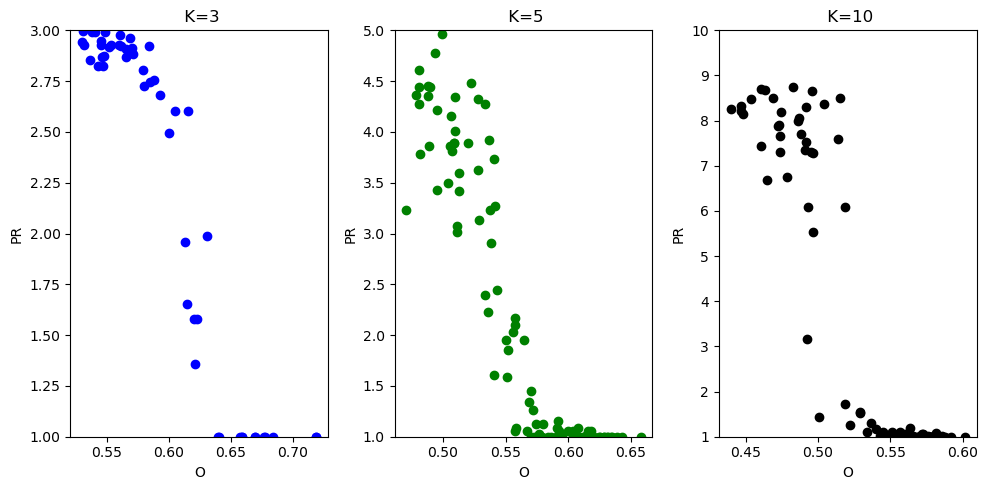

In [20]:
colors = ['blue', 'green', 'black']

fig, axs = plt.subplots(1, len(Ks), figsize=(10, 5))

for i, K in enumerate(Ks):
    ax = axs[i]
    x_values = list(popolazioni[K].keys())
    y_values = np.array(list(popolazioni[K].values()))
    
    ax.scatter(x_values, y_values, marker='o', color=colors[i], label=f"K={K}")
    ax.set_ylim(1, K)  # Imposto l'asse y da 1 a K
    ax.set_title(f" K={K}")
    ax.set_xlabel("O")
    ax.set_ylabel("PR")

plt.tight_layout()
plt.show()

In [ ]:
popolazionii = {}
Ks = [3,5,10]
eps = 0.1
alphas = [0.0167, 0.01 , 0.005 , 0.0025 , 0.00167]
times = [ 100000,3000000,10000000,3000000,500000 ]
n_points = 100
entropy_ranges = {
    3: np.linspace(0.8, 1.6, n_points),
    5: np.linspace(1.6, 2.4, n_points),
    10: np.linspace(2.5, 3.7, n_points),
    20: np.linspace(3.6, 4.3, n_points),
    30: np.linspace(4.2, 5.5, n_points),
}

for i in range(3):
    print('K', Ks[i])
    alpha = alphas[i]
    K = Ks[i]
    time = times[i]
    popolazionii[K] = {}
    

    for entropy_threshold in entropy_ranges[K]:
        pop = generate_population(K, 80, entropy_threshold)
        o = calculate_total_overlap(pop)
        pop_evoluta, storico = evolve_population(pop, time, eps, alpha)
        cluster_labels = hierarchical_clustering_K(pop_evoluta, 0.8)
        pr_value = compute_PR(cluster_labels)
        popolazionii[K][o] = pr_value

K 3
K 5


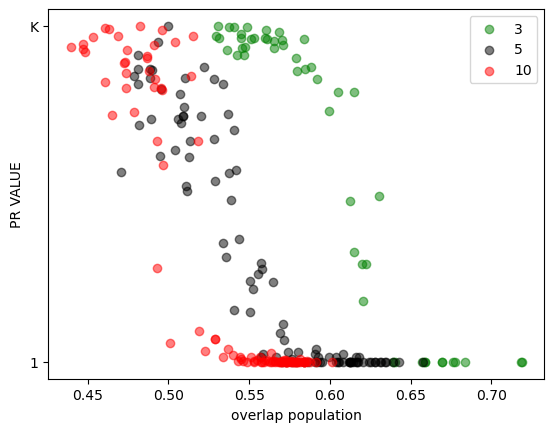

In [47]:
colors = ['green' , 'black' , 'red']
for i,K in enumerate(Ks):
    
    x_values = list(popolazioni[K].keys()) 
    y_values = np.array(list(popolazioni[K].values())) 
    x_min = y_values.min()
    x_max = y_values.max()
    data_normalized = 1 + (y_values - x_min) * (5 - 1) / (x_max - x_min)
    plt.scatter(x_values,  data_normalized ,alpha = 0.5 , color = colors[i] , label = f'{K}')
    plt.yticks([1, 5], labels=["1", "K"])

plt.xlabel('overlap population')
plt.ylabel('PR VALUE')
plt.legend()
plt.savefig('PHASE_TRANSITION_SIRBU_LORETO')

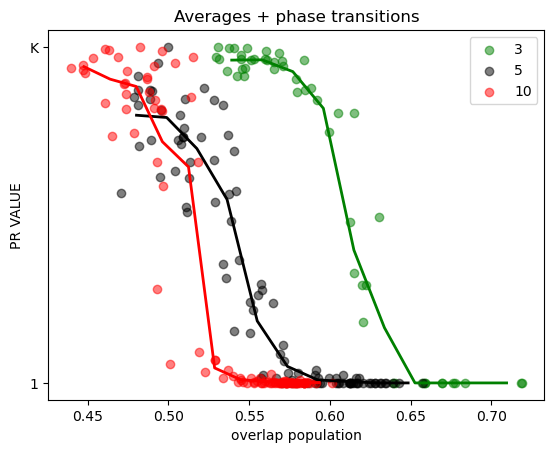

In [86]:
import numpy as np
import matplotlib.pyplot as plt

colors = ['green', 'black', 'red']
bin_count = 10
bin_averages = {}

for i, K in enumerate(Ks):
    x_values = np.array(list(popolazioni[K].keys()))
    y_values = np.array(list(popolazioni[K].values()))

   
    x_min = y_values.min()
    x_max = y_values.max()
    data_normalized = 1 + (y_values - x_min) * (5 - 1) / (x_max - x_min)

    
    plt.scatter(x_values, data_normalized, alpha=0.5, color=colors[i], label=f'{K}')

    
    bins = np.linspace(x_values.min(), x_values.max(), bin_count + 1)
    bin_indices = np.digitize(x_values, bins)

    bin_means = []
    bin_centers = []

    for j in range(1, bin_count + 1):
        bin_mask = bin_indices == j
        if np.any(bin_mask):
            mean_value = data_normalized[bin_mask].mean()
            bin_means.append(mean_value)
            bin_centers.append((bins[j - 1] + bins[j]) / 2)

    bin_averages[K] = (np.array(bin_centers), np.array(bin_means))

for i, K in enumerate(Ks):
    x_avg, y_avg = bin_averages[K]
    plt.plot(x_avg, y_avg, color=colors[i], linewidth=2)

plt.yticks([1, 5], labels=["1", "K"])
plt.xlabel('overlap population')
plt.ylabel('PR VALUE')
plt.legend()
plt.title('Averages + phase transitions')
plt.savefig('PHASE_TRANSITION_SIRBU_LORETO_averages')


In [32]:
x_max

8.743169398907105

In [6]:
popolazioni[10] = []
popolazioni[10] =  {0.4395401092825807: 8.268733850129198,
  0.4911888542463083: 7.339449541284404,
  0.48818517708331266: 7.710843373493976,
  0.48691171878601286: 8.060453400503778,
  0.4723615024775281: 7.8817733990147785,
  0.4467387892674185: 8.205128205128204,
  0.4632547992052276: 8.672086720867208,
  0.46076757920182215: 8.695652173913043,
  0.46889685047286755: 8.51063829787234,
  0.4481694525753463: 8.142493638676845,
  0.4736484461006046: 7.30593607305936,
  0.46482621525347956: 6.680584551148225,
  0.4469413840795858: 8.333333333333334,
  0.4732394870482907: 7.901234567901234,
  0.491316343052032: 8.311688311688311,
  0.45340090508042735: 8.488063660477454,
  0.478515891682993: 6.751054852320675,
  0.4608346986764357: 7.441860465116279,
  0.4825218989373874: 8.743169398907105,
  0.4915845950960844: 7.529411764705882,
  0.4863825308043475: 8.0,
  0.4733527907292398: 7.655502392344498,
  0.49268186327206487: 6.083650190114068,
  0.49646522755004824: 5.526770293609672,
  0.49256779004194545: 3.155818540433925,
  0.474518710283628: 8.184143222506394,
  0.4953232275226275: 7.30593607305936,
  0.49604588636441516: 8.64864864864865,
  0.5186584464626223: 1.7232094776521272,
  0.5223253421569535: 1.26232741617357,
  0.5042452158022974: 8.37696335078534,
  0.5008093578684722: 1.4460009037505648,
  0.5138819813250888: 7.5829383886255926,
  0.51829448667527: 6.095238095238095,
  0.5154125680733936: 8.51063829787234,
  0.4962809486373547: 7.2727272727272725,
  0.5462676081653198: 1.0253123998718359,
  0.529038306340485: 1.537722248918789,
  0.5291125094294267: 1.5274463007159904,
  0.5366581832950685: 1.293974929235746,
  0.5531773589864853: 1.0,
  0.5397486595556432: 1.1657559198542806,
  0.5551418537357717: 1.0512483574244416,
  0.5448557832342811: 1.0785305021907652,
  0.54449502257574: 1.1065006915629323,
  0.5634283701670283: 1.194475550578574,
  0.5592696562724324: 1.0,
  0.543049265918792: 1.0253123998718359,
  0.5693905255317283: 1.0,
  0.5658247484249994: 1.0,
  0.5717236122377709: 1.0512483574244416,
  0.573829577469634: 1.0,
  0.57254117820854: 1.0,
  0.5695949386450908: 1.0,
  0.5700925287288064: 1.0,
  0.5628054625012057: 1.0,
  0.5805066809066214: 1.0,
  0.5570544097558315: 1.0,
  0.5732779257236704: 1.0,
  0.5650316991140573: 1.0253123998718359,
  0.572527501645587: 1.0512483574244416,
  0.5487776814582899: 1.0,
  0.5658101816103965: 1.0253123998718359,
  0.5793085729082208: 1.0,
  0.5769984746641094: 1.0,
  0.584079042939914: 1.0,
  0.5841191596817273: 1.0,
  0.5705473574772977: 1.0253123998718359,
  0.5689298219342138: 1.0,
  0.5676994990085967: 1.0,
  0.5841691963581134: 1.0,
  0.5781658135181204: 1.0,
  0.5615172289696146: 1.0253123998718359,
  0.5838221065082938: 1.0,
  0.5813530338138511: 1.0,
  0.5779387248017952: 1.0,
  0.5761081176573883: 1.0,
  0.5797421559737437: 1.0,
  0.5734968439508396: 1.0,
  0.5856120120010223: 1.0253123998718359,
  0.5914715871714123: 1.0,
  0.5758026482951308: 1.0253123998718359,
  0.5729662749211238: 1.0,
  0.5639897226853132: 1.0,
  0.5600671118600901: 1.0515938218862964,
  0.5532434793697838: 1.0253123998718359,
  0.5879445987219815: 1.0,
  0.6014553949783564: 1.0,
  0.5568956070067709: 1.1061182163843761,
  0.5730167986960288: 1.0,
  0.5509302773319635: 1.106883431338637,
  0.5851127697388943: 1.0,
  0.5707604864853298: 1.0,
  0.5776779055919838: 1.0,
  0.5813598177793923: 1.0778039744021557,
  0.5760629924293087: 1.0,
  0.5580912397211829: 1.0,
  0.5720358427601556: 1.0,
  0.5797060302491021: 1.0,
  0.5336958412093452: 1.1065006915629323}

In [15]:
popolazioni[3] = {0.5598691904475895: 2.927120669056153,
  0.5424923374914434: 2.825836216839677,
  0.5792432848431223: 2.806414662084765,
  0.536412563559506: 2.8554778554778553,
  0.5467064046509211: 2.825836216839677,
  0.551334766517912: 2.9201430274135878,
  0.5448856890755418: 2.948255114320096,
  0.529738461902912: 2.9411764705882355,
  0.5457681846829305: 2.8688524590163933,
  0.5610210781711863: 2.9236276849642007,
  0.5473833848365577: 2.87221570926143,
  0.5484829316968712: 2.9914529914529915,
  0.5403603544524688: 2.9914529914529915,
  0.5447458526238651: 2.927120669056153,
  0.5312105390243221: 2.927120669056153,
  0.5654380116232286: 2.9097387173396676,
  0.5377211437719637: 2.9914529914529915,
  0.5797646314557966: 2.728285077951002,
  0.5607067649372196: 2.976913730255164,
  0.5307430643433628: 2.998776009791922,
  0.6050381403976937: 2.6036131774707756,
  0.5684038238899556: 2.962515114873035,
  0.5528274765341671: 2.927120669056153,
  0.599794415726718: 2.494908350305499,
  0.5704434974371884: 2.9131985731272296,
  0.5838478942932581: 2.9236276849642007,
  0.5707704746617223: 2.8857479387514724,
  0.5881036769493729: 2.7559055118110236,
  0.6148814252441684: 1.6542876434841323,
  0.5844945253180395: 2.7435610302351625,
  0.5923532581491794: 2.6805251641137855,
  0.5653199658035507: 2.8688524590163933,
  0.6208521467135918: 1.3603553581343697,
  0.622657612844602: 1.5816655907036798,
  0.6125890977933404: 1.96,
  0.6197691123863719: 1.5816655907036798,
  0.6304321747362008: 1.9854132901134522,
  0.6591549633385638: 1.0,
  0.6401962551759811: 1.0,
  0.6152322959022894: 2.6036131774707756,
  0.6573381836072234: 1.0,
  0.6393355978231399: 1.0,
  0.6696450324306654: 1.0,
  0.6587935287778113: 1.0,
  0.683749356987029: 1.0,
  0.6696746028446187: 1.0,
  0.6762846577030418: 1.0,
  0.677700230725099: 1.0,
  0.7190204242529814: 1.0,
  0.7186810961718628: 1.0}

# INTRODUCO EXTERNAL INFO INTERACTION

<function matplotlib.pyplot.show(close=None, block=None)>

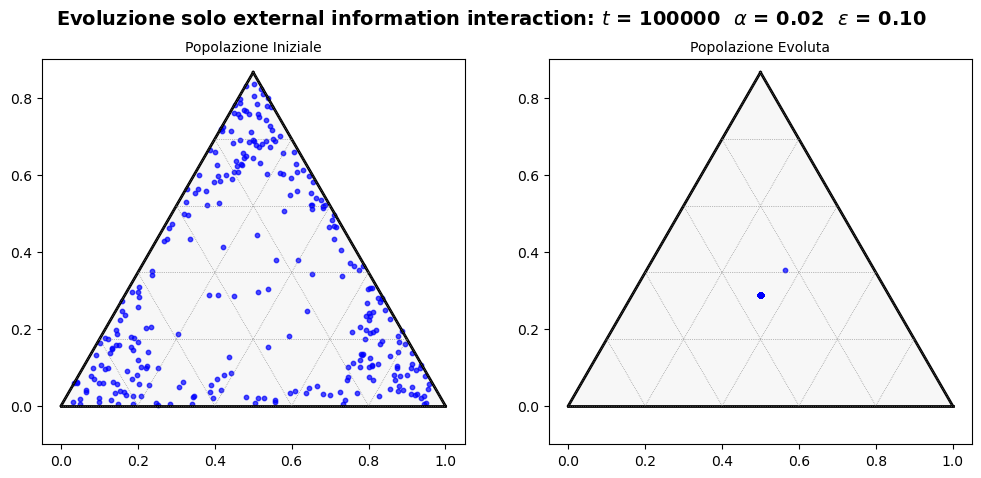

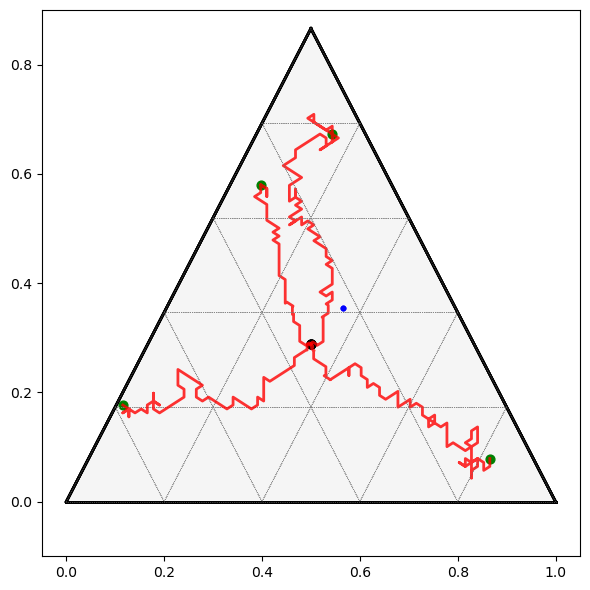

In [37]:
PI = 0.5
a = 0.333
K  = 3
I = external_info(3,a)
time = 100000
pop = generate_population( K ,300, 1.2)
pop_evoluta_with_info ,storico = evolve_population_with_info( np.array(pop) , time , 0.1, 0.0167 , I , PI)    
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) 
plt.suptitle(rf"Evoluzione solo external information interaction: $t$ = {time}  $\alpha$ = {alpha:.2f}  $\epsilon$ = {eps:.2f}", fontsize=14,  fontweight='bold')
plot_simplesso_with_ax(pop, axes[0], "Popolazione Iniziale")
plot_simplesso_with_ax(pop_evoluta_with_info, axes[1], "Popolazione Evoluta")

fig, ax = plt.subplots(figsize=(6, 6))
index_user = 23 # Cambia questo per tracciare un altro individuo
plot_user_trajectory_from_dict(storico, index_user, ax)
plot_user_trajectory_from_dict(storico,131, ax)
plot_user_trajectory_from_dict(storico, 71, ax)
plot_user_trajectory_from_dict(storico, 3, ax)

plt.tight_layout()
plt.show

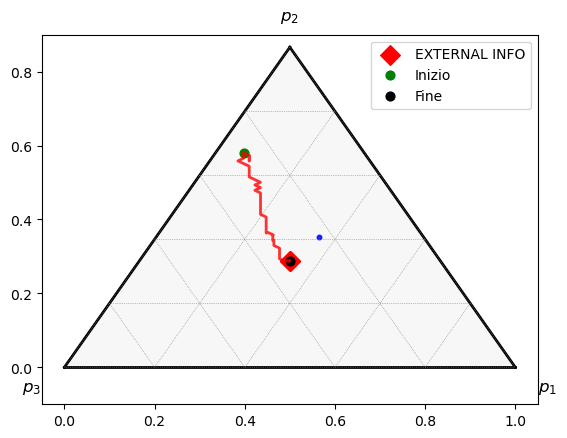

In [38]:


# Crea la figura del plot ternario
fig, tax = ternary.figure(scale=1.0)
tax.boundary(linewidth=2.0)  # Disegna il bordo del triangolo
tax.gridlines(multiple=0.2, color="gray", linewidth=0.5)  # Aggiunge una griglia

# Esempio di dati già presenti
tax.scatter(pop_evoluta_with_info, marker="o", color="blue", s=10, alpha=0.4)

# Definisci i punti medi dei lati (midpoint) 
mid_AB = I[0]   # Lato tra i vertici (1,0,0) e (0,1,0)
mid_BC = I[1]   # Lato tra i vertici (0,1,0) e (0,0,1)
mid_CA = I[2]   # Lato tra i vertici (0,0,1) e (1,0,0)
midpoints = [mid_AB, mid_BC, mid_CA]

# Aggiungi i punti medi al plot
tax.scatter(midpoints, marker="D", color="red", s=100, label="EXTERNAL INFO")
ultimo_tempo = max(storico.keys())
tax.right_corner_label("$p_1$", fontsize=12)
tax.top_corner_label("$p_2$", fontsize=12)
tax.left_corner_label("$p_3$", fontsize=12)
tax.scatter(storico[ultimo_tempo], marker="o", color="blue", s=10, alpha=0.7)
user_trajectory = [storico[t][index_user] for t in sorted(storico.keys())]
tax.plot(user_trajectory, linewidth=2, linestyle="-", color="red", markersize=5, alpha=0.8)
tax.scatter([user_trajectory[0]], marker="o", color="green", s=40, label="Inizio")  # Punto iniziale
tax.scatter([user_trajectory[-1]], marker="o", color="black", s=40, label="Fine")  # Punto finale
tax.legend()  # Visualizza la legenda, così da identificare i punti medi
tax.show()


# INTERACT WITH RANDOM INFORMATION SOUCE 

<function matplotlib.pyplot.show(close=None, block=None)>

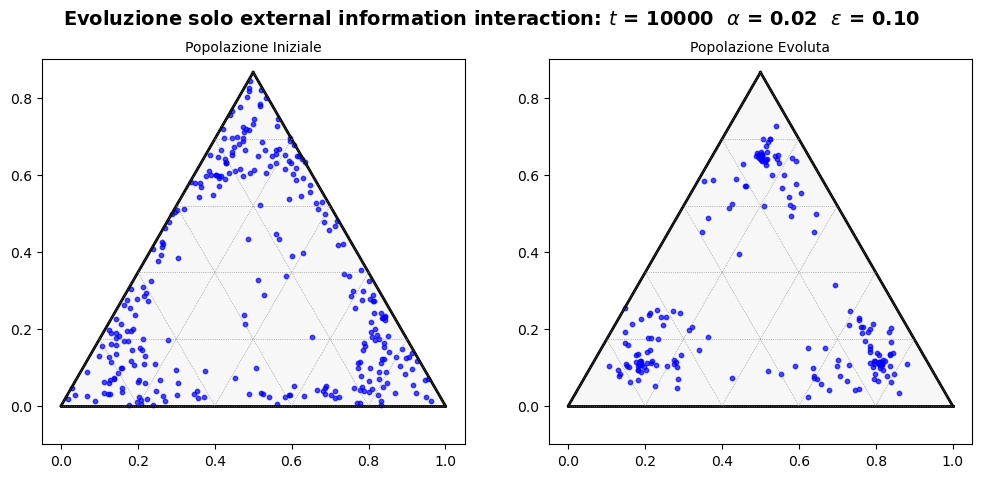

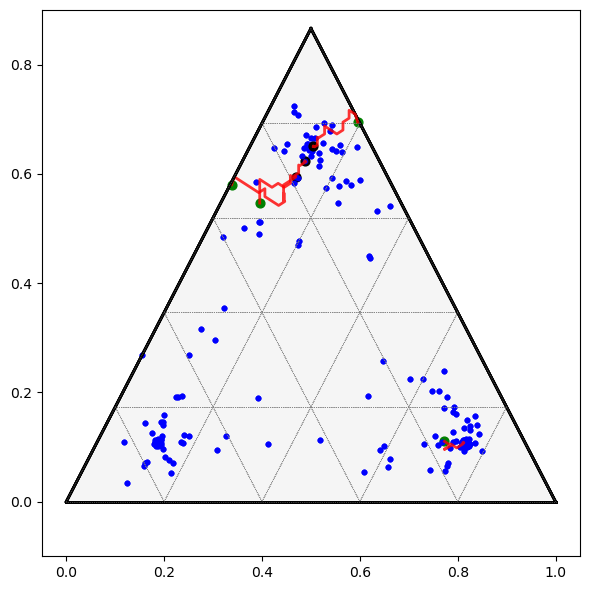

In [34]:
PI = 0.5
a = 0.75
K  = 3
I = external_info(3,a)
time = 10000
pop = generate_population( K ,300, 1.2)
pop_evoluta_with_random_info ,storico = evolve_population_with_info( np.array(pop) , time , 0.1, 0.0167 , I , PI)    
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) 
plt.suptitle(rf"Evoluzione solo external information interaction: $t$ = {time}  $\alpha$ = {alpha:.2f}  $\epsilon$ = {eps:.2f}", fontsize=14,  fontweight='bold')
plot_simplesso_with_ax(pop, axes[0], "Popolazione Iniziale")
plot_simplesso_with_ax(pop_evoluta_with_info, axes[1], "Popolazione Evoluta")

fig, ax = plt.subplots(figsize=(6, 6))
index_user = 23 # Cambia questo per tracciare un altro individuo
plot_user_trajectory_from_dict(storico, index_user, ax)
plot_user_trajectory_from_dict(storico,131, ax)
plot_user_trajectory_from_dict(storico, 71, ax)
plot_user_trajectory_from_dict(storico, 3, ax)
plt.tight_layout()
plt.show

# EXTERNAL INFO AND PEER

<function matplotlib.pyplot.show(close=None, block=None)>

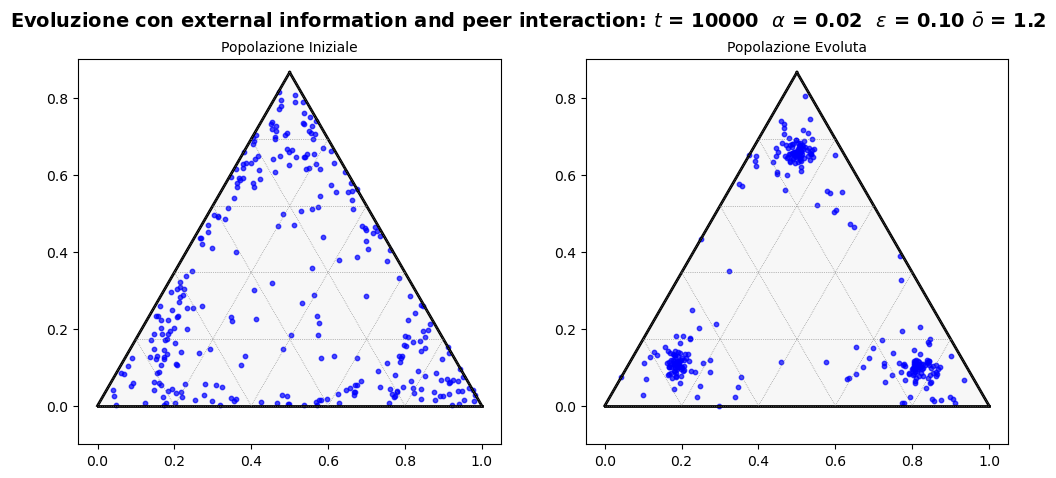

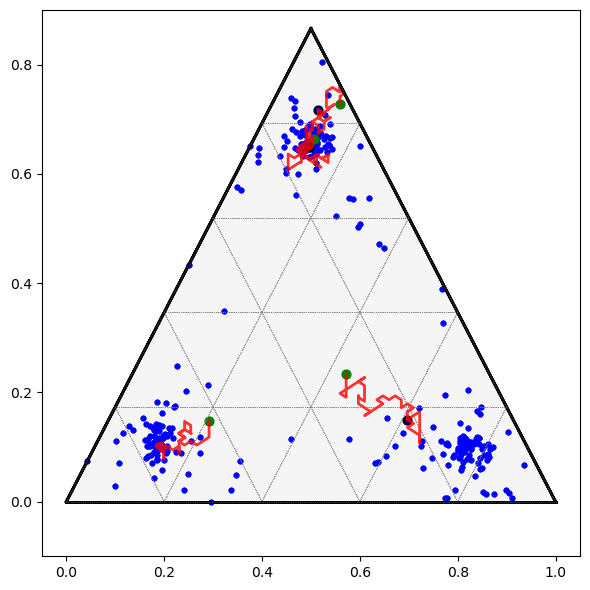

In [19]:
PI = 0.5
a = 0.75
eps = 0.1
alpha = 0.0167
I = external_info(3,a)
time = 10000
pop = generate_population( K ,300, 1.2)
pop_evoluta_with_info_and_peer ,storico = evolve_population_with_info_and_peer( np.array(pop) , time ,eps,alpha , I , PI)    
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) 
plt.suptitle(rf"Evoluzione con external information and peer interaction: $t$ = {time}  $\alpha$ = {alpha:.2f}  $\epsilon$ = {eps:.2f} $\bar{{o}}$ = 1.2", fontsize=14,  fontweight='bold')
plot_simplesso_with_ax(pop, axes[0], "Popolazione Iniziale")
plot_simplesso_with_ax(pop_evoluta_with_info_and_peer, axes[1], "Popolazione Evoluta")

fig, ax = plt.subplots(figsize=(6, 6))
index_user = 23 # Cambia questo per tracciare un altro individuo
plot_user_trajectory_from_dict(storico, index_user, ax)
plot_user_trajectory_from_dict(storico,131, ax)
plot_user_trajectory_from_dict(storico, 71, ax)
plot_user_trajectory_from_dict(storico, 3, ax)

plt.tight_layout()
plt.show